# Saliency Plots

In [1]:
from dna_features_viewer import BiopythonTranslator, GraphicFeature, GraphicRecord
from dna_features_viewer.biotools import annotate_biopython_record
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import glob, os, yaml, sparse, itertools, subprocess, sys, pickle

import Bio.SeqUtils
import Bio.Data
from Bio import SeqIO
from Bio.Seq import Seq

plt.rcParams['figure.dpi'] = 150
plt.rcParams['axes.titlepad'] = 10
import scipy.stats as st

# saliency_utils is in the utils_files directory
os.chdir("../../")
sys.path.append("utils")
from saliency_utils import *
from data_utils import *
from inSilicoMut_utils import *
import seaborn as sns
import scipy.stats as st

from sklearn.linear_model import LinearRegression
BASE_TO_COLUMN = {'A': 0, 'C': 1, 'T': 2, 'G': 3, '-': 4}

data_utils_dir = "./data_processing/data_utils"

results_dir = "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results" # change
data_dir = "/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs" # change

who_variants = pd.read_csv(f"{data_utils_dir}/WHO_catalog_V2.csv", header=[2]).reset_index(drop=True)
silent_lst = ['synonymous_variant', 'initiator_codon_variant', 'stop_retained_variant']
who_coordinates = pd.read_csv(f"{data_utils_dir}/WHO_2023_catalog_coordinates.txt", sep='\t')

cc_df = pd.read_csv(f"{data_utils_dir}/drug_CC.csv")

model_loci = pd.read_csv(f"{data_utils_dir}/drug_loci.csv")
model_loci[['Start', 'End']] = model_loci[['Start', 'End']].astype(int)

cc_dict = {'RIF': 0.5, 'INH': 0.2, 'EMB': 5, 'PZA': 100, 'ETO': 5, 'MXF': 0.5, 'LFX': 1, 'BDQ': 0.25, 'LZD': 1, 'CFZ': 1, 'DLM': 0.016}
drugs_lst = ['BDQ', 'EMB', 'ETO', 'INH', 'LFX', 'MXF', 'PZA', 'RIF']

isolate_variants = pd.read_csv("./analysis/isolate_variants_WHO_catalog.csv.gz", compression='gzip')

coll_2014 = pd.read_csv(f"{data_utils_dir}/coll2014_SNP_scheme.tsv", sep="\t")
coll_2014["lineage"] = coll_2014["#lineage"].str.replace("lineage", "")
coll_2014['position'] = coll_2014['position'].astype(str)
del coll_2014["#lineage"]

lineages_matrix = pd.read_csv(f"{data_utils_dir}/lineage_matrix_Coll2014.csv", index_col=[0])
df_samples_geno = pd.read_csv("./data_processing/samples_pass_geno_QC.csv")

h37Rv_seq = SeqIO.read(f"{data_utils_dir}/H37Rv/GCF_000195955.2_ASM19595v2_genomic.gbff", "genbank")
h37Rv_genes = pd.read_csv(f"{data_utils_dir}/H37Rv/mycobrowser_h37rv_genes_v4.csv")
h37Rv_coords_to_gene = pd.read_csv(f"{data_utils_dir}/H37Rv/h37Rv_coords_to_gene.csv.gz", compression='gzip')
h37Rv_coords_to_gene_dict = dict(zip(h37Rv_coords_to_gene['pos'], h37Rv_coords_to_gene['region']))


def get_isolates_with_variant_of_interest(pos, locus, seqDict, allele, df_phenos, drug):

    isolates_with_variant = seqDict[locus].loc[seqDict[locus][pos]==allele].index.values
    print(f"{len(isolates_with_variant)} isolates with position {pos} = {allele}")

    full_drug_name = abbr_drug_dict[drug]
    return isolate_variants.query("ROLLINGDB_ID in @isolates_with_variant & drug==@full_drug_name").drop_duplicates(['ROLLINGDB_ID', 'variant']).merge(df_phenos[['ROLLINGDB_ID', f'{drug}_lower_bound', f'{drug}_upper_bound', 'category', 'Lineage']])

# Compute the number of sites with significant saliency scores not in the WHO catalog

In [ ]:
def get_ref_nucleotide(pos, locus, drug, seqDict):

    kwargs = yaml.safe_load(open(f"config_files/config_{drug.lower()}.yaml", "r"))
    locus_idx = (kwargs['tier1_loci'] + kwargs['tier2_loci']).index(locus)
    
    return seqDict[locus].loc['MT_H37Rv', pos]
    
    
    
def get_new_sites_with_positive_saliency_scores(drug_abbr, saliency_df, seqDict, raw_scores, locus_list, score_percentile_thresh=50, freq_thresh=5):

    drug = abbr_drug_dict[drug_abbr]
    
    R_assoc_variants = who_variants.loc[who_variants['FINAL CONFIDENCE GRADING'].str.contains('Assoc w R')].query("drug==@drug").variant.unique()

    R_assoc_NT_sites = who_coordinates.query("variant in @R_assoc_variants").position.unique()

    print(f"{len(R_assoc_NT_sites)} R-associated positions in the WHO catalog for {drug_abbr}")

    print(saliency_df.query("Pos in @R_assoc_NT_sites").Max_Sig.value_counts())

    # compute the percentile using only sites with a significant Max score
    score_thresh = np.percentile(saliency_df.query("Max_Sig==1")['Max'], q=score_percentile_thresh)

    new_sites = saliency_df.query("Pos not in @R_assoc_NT_sites & Max_Sig == 1 & Min_Sig == 0 & Max >= @score_thresh").Pos.values

    df_sites_with_alt_alleles = pd.DataFrame(columns = ['Drug', 'Locus', 'POS', 'REF', 'ALT', 'Num_Isolates'])
    k = 0
    
    for pos in new_sites:
    
        # exclude the insertion sites
        if '_' not in str(pos):    

            locus = model_loci.query("Start < @pos & End >= @pos").Locus.values[0]

            locus_idx = locus_list.index(locus)

            # index of the position within the locus
            pos_idx = list(seqDict[locus].columns).index(pos)

            ref_nuc = get_ref_nucleotide(pos, locus, drug_abbr, seqDict)

            # each isolate has a saliency score, so get the maximum of the isolate-specific saliency scores for each allele 
            max_scores = np.max(raw_scores[:, :, pos_idx, locus_idx], axis=0)
            
            allele_with_highest_score = list(BASE_TO_COLUMN.keys())[np.argmax(max_scores)]

            num_alt_allele_samples = len(seqDict[locus].loc[seqDict[locus][pos] == allele_with_highest_score])
            
            if num_alt_allele_samples >= freq_thresh:
                df_sites_with_alt_alleles.loc[k, :] = [drug_abbr, locus, pos, ref_nuc, allele_with_highest_score, num_alt_allele_samples]
                k += 1
    
    return df_sites_with_alt_alleles

In [ ]:
df_total_new_sites = []

for drug in drugs_lst:
    
    kwargs = yaml.safe_load(open(f"config_files/config_{drug.lower()}.yaml", "r"))
    locus_list = kwargs['tier1_loci'] + kwargs['tier2_loci']

    if drug == 'PZA':
        model_path = f"{results_dir}/{drug}_amino_acid"
        fasta_dir = kwargs['genotype_input_directory']
    elif drug == 'BDQ':
        model_path = f"{results_dir}/{drug}_augment_lineage_amino_acid"
        fasta_dir = os.path.dirname(kwargs['genotype_input_directory']) + "_augment/fastas"
    else:
        model_path = f"{results_dir}/{drug}_lineage_amino_acid"
        fasta_dir = kwargs['genotype_input_directory']

    saliency_df, seqDict = generate_saliency_plots(drug,
                                                  model_path,
                                                  kwargs['tier1_loci'],
                                                  fasta_dir=fasta_dir,
                                                  cat_to_check=["1", "2"],
                                                  save=True,
                                                  significance=True,
                                                  sig_thresh=0.05,
                                                 )

    raw_scores = sparse.load_npz(os.path.join(results_dir, model_path, "saliency/genetic_scores_unpooled_nuc.npy.npz")).todense()

    df_sites_with_alt_alleles = get_new_sites_with_positive_saliency_scores(drug, saliency_df, seqDict, raw_scores, locus_list, score_percentile_thresh=75)
    df_total_new_sites.append(df_sites_with_alt_alleles)

df_total_new_sites = pd.concat(df_total_new_sites).reset_index(drop=True)

df_total_new_sites['POS'] = df_total_new_sites['POS'].astype(int)

df_total_new_sites['Gene'] = df_total_new_sites['POS'].map(h37Rv_coords_dict)

# leave these blank
df_total_new_sites.loc[df_total_new_sites['Gene'].str.contains('NC'), 'Gene'] = np.nan

df_total_new_sites.to_csv("supplement/new_sites_saliency_analysis.csv", index=False)

In [ ]:
import pandas as pd

In [ ]:
df_total_new_sites = pd.read_csv("./supplement/new_sites_saliency_analysis.csv")

In [ ]:
df_total_new_sites.POS.nunique(), len(df_total_new_sites)

In [ ]:
(96+88)/(244)

In [ ]:
df_total_new_sites.groupby("Drug").POS.nunique().sort_values(ascending=False)

In [ ]:
df_total_new_sites.query("Drug=='BDQ'")

In [ ]:
141/247

In [ ]:
df_total_new_sites.groupby("Locus").POS.nunique().sort_values(ascending=False)

# Bedaquiline

In [ ]:
model_path

In [ ]:
drug = 'BDQ'

kwargs = yaml.safe_load(open(f"config_files/config_{drug.lower()}.yaml", "r"))
model_path = os.path.join(results_dir, f"{drug}_augment_lineage_amino_acid")

BDQ_df, BDQ_seqDict = generate_saliency_plots(drug,
                                      model_path,
                                      kwargs['tier1_loci'],
                                      fasta_dir="/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/BDQ_augment/fastas",
                                      cat_to_check=["1"],
                                      save=True,
                                      significance=True,
                                      sig_thresh=0.05,
                                     )

# ETO_scores = sparse.load_npz(os.path.join(results_dir, f"{model_path}/saliency/genetic_scores_unpooled_nuc.npy.npz")).todense()

# Ethionamide

In [ ]:
df_ETO = pd.read_csv(f"{data_dir}/ETO/data_for_model.csv")

In [ ]:
drug = 'ETO'
kwargs = yaml.safe_load(open(f"config_files/config_{drug.lower()}.yaml", "r"))
model_path = os.path.join(results_dir, f"{drug}_lineage_amino_acid")

ETO_df, ETO_seqDict = generate_saliency_plots(drug,
                                      model_path,
                                      kwargs['tier1_loci'],
                                      fasta_dir=kwargs['genotype_input_directory'],
                                      cat_to_check=["1"],
                                      save=False,
                                      significance=True,
                                      sig_thresh=0.05,
                                     )

# ETO_scores = sparse.load_npz(os.path.join(results_dir, f"{model_path}/saliency/genetic_scores_unpooled_nuc.npy.npz")).todense()

## Correlate ethA SSM with Saliency scores

In [ ]:
df_ethA_SSM = pd.read_csv(f"{results_dir}/ETO_lineage_amino_acid/inSilico_analysis/saturation_mutagenesis/ethA/test_predictions.csv")

ETO_H37Rv_pred = df_ethA_SSM.query("ROLLINGDB_ID == 'MT_H37Rv'").pred_MIC.values[0]

df_ethA_SSM = df_ethA_SSM.query("ROLLINGDB_ID != 'MT_H37Rv' &~ROLLINGDB_ID.str.contains('\*')")

ethA_start, ethA_end, ethA_sense = h37Rv_genes.query("Symbol=='ethA'")[['Start', 'End', 'Strand']].values[0]

df_ethA_SSM['Codon'] = df_ethA_SSM['ROLLINGDB_ID'].apply(get_variant_number, args=(ethA_sense))

# no nonsense mutations
assert len(df_ethA_SSM) == df_ethA_SSM['Codon'].max() * 19

df_ethA_SSM['ref_pred'] = ETO_H37Rv_pred

df_ethA_SSM['fold_change'] = df_ethA_SSM['pred_MIC'] / df_ethA_SSM['ref_pred']

df_ethA_FC_by_codon = pd.DataFrame(df_ethA_SSM.groupby('Codon')['fold_change'].mean()).reset_index()

In [ ]:
ethA_saliency = ETO_df.query("Gene == 'ethA'")

ethA_saliency['Pos_String'] = ethA_saliency['Pos'].astype(str)
ethA_saliency = ethA_saliency.query("~Pos_String.str.contains('_')")
ethA_saliency['Pos'] = ethA_saliency['Pos'].astype(int)

del ethA_saliency['Pos_String']

if ethA_sense == '+':
    last_pos_before_stop_codon = ethA_end - 3
    ethA_saliency = ethA_saliency.query("Pos >= @ethA_start & Pos <= @last_pos_before_stop_codon").reset_index(drop=True)

elif ethA_sense == '-':
    last_pos_before_stop_codon = ethA_start + 3
    ethA_saliency = ethA_saliency.query("Pos >= @last_pos_before_stop_codon & Pos <= @ethA_end").reset_index(drop=True)

assert len(ethA_saliency) / 3 == len(df_ethA_FC_by_codon)

In [ ]:
if ethA_sense == '+':
    ethA_saliency['Pos_from_Start_Codon'] = ethA_saliency['Pos'] - ethA_start
elif ethA_sense == '-':
    ethA_saliency['Pos_from_Start_Codon'] = ethA_end - ethA_saliency['Pos']

# add 1 at the end because they are 0-indexed codons at first
ethA_saliency['Codon'] = np.floor((ethA_saliency['Pos_from_Start_Codon']) / 3).astype(int) + 1

In [ ]:
for i, row in ethA_saliency.iterrows():
    if row['Max_Sig'] == 0:
        ethA_saliency.loc[i, 'Max'] = np.nan
    elif row['Min_Sig'] == 0:
        ethA_saliency.loc[i, 'Min'] = np.nan

In [ ]:
ethA_saliency_by_codon = ethA_saliency.groupby('Codon')[['Max', 'Min']].mean().reset_index()

assert len(ethA_saliency_by_codon.dropna(subset=['Max', 'Min'], how='all')) == len(ethA_saliency_by_codon)

df_ethA_FC_saliency_by_codon = df_ethA_FC_by_codon.merge(ethA_saliency_by_codon)

In [ ]:
df_ethA_FC_saliency_by_codon

In [ ]:
codons_significant_pos_saliency = ethA_saliency.query("Max_Sig==1 & Max > 0.01").Codon.unique()
len(codons_significant_pos_saliency)

In [ ]:
df_ethA_FC_saliency_by_codon['Significant_Max_Saliency'] = df_ethA_FC_saliency_by_codon['Codon'].isin(codons_significant_pos_saliency).astype(int)

In [ ]:
df_ethA_FC_saliency_by_codon.Significant_Max_Saliency.value_counts()

In [ ]:
Sites in codons with a significant positive saliency score greater than 0.01 have significantly higher average predicted fold change for missense mutations (p << 0.01, Mann-Whitney U test) than other sites. There are 164 such codons, with an average predicted fold change of 1.32, while the average predicted fold change for the other 325 codons is 1.10.

In [ ]:
# st.ttest_ind(np.log2(df_ethA_FC_saliency_by_codon.query("Significant_Max_Saliency==1").fold_change),
#              np.log2(df_ethA_FC_saliency_by_codon.query("Significant_Max_Saliency==0").fold_change),
#              alternative='greater'
#             )

In [ ]:
st.mannwhitneyu(df_ethA_FC_saliency_by_codon.query("Significant_Max_Saliency==1").fold_change,
             df_ethA_FC_saliency_by_codon.query("Significant_Max_Saliency==0").fold_change,
             alternative='greater'
            )

In [ ]:
df_ethA_FC_saliency_by_codon.groupby("Significant_Max_Saliency")['fold_change'].mean()

In [ ]:
# for i, row in df_ethA_FC_saliency_by_codon.iterrows():

#     if row['Max'] >= abs(row['Min']):
#         df_ethA_FC_saliency_by_codon.loc[i, 'saliency_score'] = row['Max']
#     else:
#         df_ethA_FC_saliency_by_codon.loc[i, 'saliency_score'] = row['Min']

In [ ]:
df_ethA_FC_saliency_by_codon['Mean'] = df_ethA_FC_saliency_by_codon[['Max', 'Min']].mean(axis=1)

In [ ]:
df_ethA_FC_saliency_by_codon

In [ ]:
# sns.scatterplot(data=df_ethA_FC_saliency_by_codon,
#                 x='fold_change',
#                 y='Max'
#                )

# plt.xscale('log', base=2)

In [ ]:
st.pearsonr(np.log2(df_ethA_FC_saliency_by_codon['fold_change']), df_ethA_FC_saliency_by_codon['Mean'])

In [ ]:
st.spearmanr(df_ethA_FC_saliency_by_codon['fold_change'], df_ethA_FC_saliency_by_codon['Mean'])

In [ ]:
df_ethA_FC_saliency_by_codon.query("fold_change > 4")

In [ ]:
# df_ethA_SSM.query("Codon in [303, 479]")#.drop_duplicates('Codon')

In [ ]:
ETO_df.query("Gene=='mshA' & Max_Sig==1").sort_values("Max", ascending=False)

In [ ]:
pos = 575436
locus = 'mshA'

locus_idx = kwargs['tier1_loci'].index(locus)
ref = ETO_seqDict[locus].loc['MT_H37Rv', pos]

# don't need to reset index because indices across loci were not reset
idx = ETO_df.query("Pos==@pos").index.values[0] 
print(f"Reference: {ref}")

# ETH_seqDict[locus].loc[ETH_seqDict[locus][pos] != ref][pos].value_counts()

max_scores = np.max(ETO_scores[:, :, idx, locus_idx], axis=0)
min_scores = np.min(ETO_scores[:, :, idx, locus_idx], axis=0)
dict(zip(BASE_TO_COLUMN.keys(), max_scores)), dict(zip(BASE_TO_COLUMN.keys(), min_scores))

In [ ]:
get_isolates_with_variant_of_interest(pos, locus, ETO_seqDict, 'T', df_ETO, 'ETO')

In [ ]:
df_ETO_tier2_insilico_pred = pd.read_csv("./results/Ethionamide/insilico_pred_tier2.csv")

In [ ]:
addl_high_MIC = df_ETO_tier2_insilico_pred.query("gene in ['ndh', 'mshA', 'Rv3083', 'Rv0565c'] & fold_change > 2")
len(addl_high_MIC)

In [ ]:
addl_high_MIC.gene.value_counts()

In [ ]:
addl_high_MIC.effect.value_counts()

In [ ]:
addl_high_MIC[['gene', 'effect']].value_counts()

In [ ]:
addl_high_MIC.query("effect=='missense_variant'")

In [ ]:
addl_high_MIC.sort_values(['gene', 'pred_MIC'], ascending=[True, False]).to_csv("./results/Ethionamide/new_genes_greater_doubling.csv", index=False)

In [ ]:
drug = 'ETO'
kwargs = yaml.safe_load(open(f"config_files/config_{drug.lower()}.yaml", "r"))
model_path = os.path.join(results_dir, f"{drug}_lineage_tier2_amino_acid")

ETO_tier2_df, ETO_tier2_seqDict = generate_saliency_plots(drug,
                                              model_path,
                                              kwargs['tier1_loci'] + kwargs['tier2_loci'],
                                              fasta_dir=kwargs['genotype_input_directory'],
                                              cat_to_check=["1"],
                                              save=True,
                                              significance=True,
                                              sig_thresh=0.05,
                                             )

ETO_tier2_scores = sparse.load_npz(os.path.join(results_dir, f"{model_path}/saliency/genetic_scores_unpooled_nuc.npy.npz")).todense()

In [ ]:
def get_NT_with_max_score(locus, pos, saliency_df, scores_array):

    locus_idx = (kwargs['tier1_loci'] + kwargs['tier2_loci']).index(locus)
    idx = saliency_df.query("Pos==@pos").index.values[0] 

    max_scores = np.max(scores_array[:, :, idx, locus_idx], axis=0)
    # min_scores = np.min(scores_array[:, :, idx, locus_idx], axis=0)
    
    base_with_max_score = list(BASE_TO_COLUMN.keys())[max_scores.argmax()]
    # base_with_min_score = list(BASE_TO_COLUMN.keys())[min_scores.argmin()]

    return np.max(max_scores), base_with_max_score#, base_with_min_score

In [ ]:
df_ndh_NTs_with_max_score = pd.DataFrame(columns = ['Pos', 'Max', 'NT'])
i = 0

for pos in ETO_tier2_df.query("Gene=='ndh'").Pos.values:
    max_score, NT_max_score = get_NT_with_max_score('ndh', pos, ETO_tier2_df, ETO_tier2_scores)
    df_ndh_NTs_with_max_score.loc[i, :]  = [pos, max_score, NT_max_score]
    i += 1

In [ ]:
df_mshA_NTs_with_max_score = pd.DataFrame(columns = ['Pos', 'Max', 'NT'])
i = 0

for pos in ETO_tier2_df.query("Gene=='mshA'").Pos.values:
    max_score, NT_max_score = get_NT_with_max_score('mshA', pos, ETO_tier2_df, ETO_tier2_scores)
    df_mshA_NTs_with_max_score.loc[i, :]  = [pos, max_score, NT_max_score]
    i += 1

In [ ]:
df_mshA_NTs_with_max_score.query("Max > 0").sort_values("Max", ascending=False)

In [ ]:
who_variants.query("variant=='ethA_p.Asn287_Leu333del'")[['Present_SOLO_S', 'Present_SOLO_R', 'Present_S', 'Present_R']]

In [ ]:
get_isolates_with_variant_of_interest(575907, 'mshA', ETO_tier2_seqDict, 'T', df_ETO, 'ETO')

In [ ]:
df_ndh_NTs_with_max_score.query("Max > 0").sort_values("Max", ascending=False)

In [ ]:
get_isolates_with_variant_of_interest('ndh_20', locus, ETO_tier2_seqDict, 'G', df_ETO, 'ETO')

In [ ]:
samples_with_ndh_LoF = isolate_variants.query("GENE=='ndh' & EFFECT in ['frameshift_variant', 'stop_gained']").merge(df_ETO[['ROLLINGDB_ID', 'category', 'Binary']]).ROLLINGDB_ID.unique()

len(samples_with_ndh_LoF)

In [ ]:
positions_with_fs = isolate_variants.query("GENE=='ndh' & EFFECT in ['frameshift_variant', 'stop_gained']").merge(df_ETO[['ROLLINGDB_ID', 'category', 'Binary']]).drop_duplicates(['ROLLINGDB_ID', 'variant'])[['ROLLINGDB_ID', 'POS', 'REF', 'ALT', 'variant']][['POS', 'REF', 'ALT']].POS.unique()

isolate_variants.query("GENE=='ndh' & EFFECT in ['frameshift_variant', 'stop_gained']").merge(df_ETO[['ROLLINGDB_ID', 'category', 'Binary']]).drop_duplicates(['ROLLINGDB_ID', 'variant'])[['ROLLINGDB_ID', 'POS', 'REF', 'ALT', 'variant']][['POS', 'REF', 'ALT']].value_counts()

In [ ]:
ETO_tier2_seqDict['ndh'].loc[samples_with_ndh_LoF][2102039]

In [ ]:
ETO_tier2_df.query("Gene=='mshA'").sort_values("Max", ascending=False)

In [ ]:
pos = 576051
locus = 'mshA'

locus_idx = (kwargs['tier1_loci'] + kwargs['tier2_loci']).index(locus)
ref = ETO_tier2_seqDict[locus].loc['MT_H37Rv', pos]

# don't need to reset index because indices across loci were not reset
idx = ETO_tier2_df.query("Pos==@pos").index.values[0] 
print(f"Reference: {ref}")

# ETH_seqDict[locus].loc[ETH_seqDict[locus][pos] != ref][pos].value_counts()

max_scores = np.max(ETO_tier2_scores[:, :, idx, locus_idx], axis=0)
min_scores = np.min(ETO_tier2_scores[:, :, idx, locus_idx], axis=0)
dict(zip(BASE_TO_COLUMN.keys(), max_scores)), dict(zip(BASE_TO_COLUMN.keys(), min_scores))

In [ ]:
get_isolates_with_variant_of_interest(pos, locus, ETO_tier2_seqDict, '-', df_ETO, 'ETO')

In [ ]:
ETO_tier2_df.query("Gene=='Rv0565c'").sort_values("Max", ascending=False)

In [ ]:
pos = 656522
locus = 'Rv0565c'

locus_idx = (kwargs['tier1_loci'] + kwargs['tier2_loci']).index(locus)
ref = ETO_tier2_seqDict[locus].loc['MT_H37Rv', pos]

# don't need to reset index because indices across loci were not reset
idx = ETO_tier2_df.query("Pos==@pos").index.values[0] 
print(f"Reference: {ref}")

# ETH_seqDict[locus].loc[ETH_seqDict[locus][pos] != ref][pos].value_counts()

max_scores = np.max(ETO_tier2_scores[:, :, idx, locus_idx], axis=0)
min_scores = np.min(ETO_tier2_scores[:, :, idx, locus_idx], axis=0)
dict(zip(BASE_TO_COLUMN.keys(), max_scores)), dict(zip(BASE_TO_COLUMN.keys(), min_scores))

In [ ]:
get_isolates_with_variant_of_interest(pos, locus, ETO_tier2_seqDict, 'C', df_ETO, 'ETO')

In [ ]:
isolate_variants.query("variant=='ndh_p.Ala324fs'").drop_duplicates('ROLLINGDB_ID').merge(df_ETO)

In [ ]:
ETO_tier2_df.query("Gene=='ndh'").sort_values("Max", ascending=False)

In [ ]:
pos = 2103028
locus = 'ndh'

locus_idx = (kwargs['tier1_loci'] + kwargs['tier2_loci']).index(locus)
ref = ETO_tier2_seqDict[locus].loc['MT_H37Rv', pos]

# don't need to reset index because indices across loci were not reset
idx = ETO_tier2_df.query("Pos==@pos").index.values[0] 
print(f"Reference: {ref}")

# ETH_seqDict[locus].loc[ETH_seqDict[locus][pos] != ref][pos].value_counts()

max_scores = np.max(ETO_tier2_scores[:, :, idx, locus_idx], axis=0)
min_scores = np.min(ETO_tier2_scores[:, :, idx, locus_idx], axis=0)
dict(zip(BASE_TO_COLUMN.keys(), max_scores)), dict(zip(BASE_TO_COLUMN.keys(), min_scores))

In [ ]:
get_isolates_with_variant_of_interest(pos, locus, ETO_tier2_seqDict, '-', df_ETO, 'ETO')

In [ ]:
ETO_tier2_df.query("Gene=='Rv3083'").sort_values("Max", ascending=False).head(10)

In [ ]:
pos = 3448548
locus = 'Rv3083'

locus_idx = (kwargs['tier1_loci'] + kwargs['tier2_loci']).index(locus)
ref = ETO_tier2_seqDict[locus].loc['MT_H37Rv', pos]

# don't need to reset index because indices across loci were not reset
idx = ETO_tier2_df.query("Pos==@pos").index.values[0] 
print(f"Reference: {ref}")

# ETH_seqDict[locus].loc[ETH_seqDict[locus][pos] != ref][pos].value_counts()

max_scores = np.max(ETO_tier2_scores[:, :, idx, locus_idx], axis=0)
min_scores = np.min(ETO_tier2_scores[:, :, idx, locus_idx], axis=0)
dict(zip(BASE_TO_COLUMN.keys(), max_scores)), dict(zip(BASE_TO_COLUMN.keys(), min_scores))

In [ ]:
Rv3083_deletions = get_isolates_with_variant_of_interest(pos, locus, ETO_tier2_seqDict, '-', df_ETO, 'ETO').query("GENE==@locus")

In [ ]:
Rv3083_deletions#[['ROLLINGDB_ID', 'POS', 'REF', 'ALT']]

In [ ]:
Rv3083_deletions['Deletion_Length'] = Rv3083_deletions['REF'].str.len() - Rv3083_deletions['ALT'].str.len()

In [ ]:
Rv3083_deletions.query("variant=='Rv3083_LoF'")[['POS', 'REF', 'ALT', 'Deletion_Length']].drop_duplicates().sort_values("POS")

In [ ]:
Rv3083_deletions.query("variant=='Rv3083_LoF'")['EFFECT'].unique()

In [ ]:
Rv3083_deletions.query("variant=='Rv3083_LoF'").merge(df_ETO[['ETO_lower_bound', 'ETO_midpoint', 'Binary', 'ETO_upper_bound', 'ROLLINGDB_ID']]).ETO_midpoint.mean()#.ROLLINGDB_ID.nunique()

In [ ]:
Rv3083_deletions.query("variant=='Rv3083_LoF'").merge(df_ETO[['ETO_lower_bound', 'ETO_midpoint', 'Binary', 'ETO_upper_bound', 'ROLLINGDB_ID']]).Binary.value_counts()

In [ ]:
pos = 657428
locus = 'Rv0565c'

locus_idx = (kwargs['tier1_loci'] + kwargs['tier2_loci']).index(locus)
ref = ETH_seqDict[locus].loc['MT_H37Rv', pos]

# don't need to reset index because indices across loci were not reset
idx = ETH_tier2_df.query("Pos==@pos").index.values[0] 
print(f"Reference: {ref}")

# ETH_seqDict[locus].loc[ETH_seqDict[locus][pos] != ref][pos].value_counts()

max_scores = np.max(ETH_tier2_scores[:, :, idx, locus_idx], axis=0)
min_scores = np.min(ETH_tier2_scores[:, :, idx, locus_idx], axis=0)
dict(zip(BASE_TO_COLUMN.keys(), max_scores)), dict(zip(BASE_TO_COLUMN.keys(), min_scores))

In [ ]:
isolate_variants.query("POS==@pos")

In [ ]:
isolate_variants.query("ROLLINGDB_ID=='SAMEA8741644' & drug=='Ethionamide'")

In [ ]:
df_ETO_phenos = pd.read_csv(os.path.join(data_dir, "ETH", "data_for_model.csv"))

In [ ]:
df_ETO_phenos.query("ROLLINGDB_ID=='SAMEA8741644'")

# Pyrazinamide

In [ ]:
drug = 'PZA'
kwargs = yaml.safe_load(open(f"config_files/config_{drug.lower()}.yaml", "r"))
model_path = os.path.join(results_dir, f"{drug}_amino_acid")

PZA_df, PZA_seqDict = generate_saliency_plots(drug,
                                              model_path,
                                              kwargs['tier1_loci'],
                                              fasta_dir=kwargs['genotype_input_directory'],
                                              cat_to_check=["1"],
                                              save=True,
                                              significance=True,
                                              sig_thresh=0.05,
                                             )

PZA_scores = sparse.load_npz(os.path.join(results_dir, f"{model_path}/saliency/genetic_scores_unpooled_nuc.npy.npz")).todense()

In [ ]:
model_loci.query("Locus=='clpC1'")

# Lineage Saliency Plots

In [11]:
def generate_lineage_saliency_plot(drug, model_path, lineage_mat=lineages_matrix, annot_thresh=0.25, significance=True, savefName=None):
    
    df_phenos = pd.read_csv(os.path.join(data_dir, drug, "data_for_model.csv")).query("category=='train_set'")
    df_phenos["log2_MIC"] = np.log2(df_phenos[f"{drug}_midpoint"])
    mean_log_mic = np.mean(df_phenos["log2_MIC"])
    
    
    ################################### STEP 1: MAKE A DATAFRAME OF THE LINEAGE SNPS (AND PEPTIDE LENGTHS, IF SO) WITH SCORES ###################################


    if "_peptide" in model_path:
        genes_lst = pd.read_csv(os.path.join(results_dir, drug, "gene_peptide_lengths.csv"), index_col=[0]).columns
        genes_lst = [gene.replace("_length", "") for gene in genes_lst]
    else:
        genes_lst = []
        
    # get only the training or testing set and subset the lineage matrix too
    lineage_mat = lineage_mat.loc[df_phenos["ROLLINGDB_ID"]]
    
    saliency_dir = os.path.join(results_dir, model_path, "saliency")
        
    # get lineage scores for the primary model
    lineage_scores = np.load(os.path.join(saliency_dir, "mlp_scores.npy"))
    
    # create a dataframe with lineages, scores, and average log-MIC of isolates
    lineage_scores_df = pd.DataFrame({"position": list(genes_lst) + list(lineage_mat.columns), 
                                      "Max": lineage_scores.max(axis=0), 
                                      "Min": lineage_scores.min(axis=0),
                                      # 'Mean': lineage_scores.mean(axis=0), # take the average activation of each lineage SNP across the training isolates
                                     })
    
    lineage_scores_df = lineage_scores_df.merge(coll_2014[["lineage", "position"]], on="position")
    

    ################################### STEP 2: COMPUTE AVERAGE MIC OF EACH LINEAGE DIVIDED BY AVERAGE OF THE WHOLE DATASET ###################################


    lineage_scores_df['Mean_log2_MIC'] = mean_log_mic
    
    # add log2-MIC to get averaged per lineage later
    lineage_mat = lineage_mat.merge(df_phenos[["ROLLINGDB_ID", "log2_MIC"]].set_index("ROLLINGDB_ID"), left_index=True, right_index=True)

    # get the prediction for H37Rv from the in silico analysis directory
    df_insilico = pd.read_csv(os.path.join(results_dir, model_path, "inSilico_analysis", "lineage_SNP_predictions.csv"))
    H37Rv_pred = df_insilico.query("Lineage=='MT_H37Rv'")['log2_pred_MIC'].values[0]
    
    for i, row in lineage_scores_df.iterrows():

        # add average log2-MIC of isolates with that SNP
        log2_MIC = lineage_mat.loc[lineage_mat[row["position"]]==1]["log2_MIC"].mean()
        lineage_scores_df.loc[i, ["log2_MIC", "MIC"]] = [log2_MIC, np.exp2(log2_MIC)]
    
        # then perform a hypothesis test for MIC enrichment (greater or less than the mean)
        pos, lineage = row["position"], row["lineage"]

        isolates_in_lineage = lineage_mat.loc[df_phenos["ROLLINGDB_ID"].values].loc[lineage_mat[pos]==1].index.values

        # keep track of the number of training isolates of each lineae
        lineage_scores_df.loc[i, 'Num_Isolates'] = len(isolates_in_lineage)

        # hypothesis test to compare mean of isolates in a particular lineage to the entire dataset
        if len(isolates_in_lineage) > 0:

            if log2_MIC > mean_log_mic:
                alt = "greater"
            else:
                alt = "less"

            mu_stat, mu_pval = st.mannwhitneyu(df_phenos.query("ROLLINGDB_ID in @isolates_in_lineage")[f"{drug}_midpoint"].values, 
                                               df_phenos[f"{drug}_midpoint"].values,
                                               alternative=alt,
                                              )

            lineage_scores_df.loc[i, "MIC_pval"] = mu_pval
        
        else:
            lineage_scores_df.loc[i, "MIC_pval"] = np.nan

        
    ################################### STEP 3: GET P-VALUES FOR USING PERMUTATION MODEL SCORES ###################################

    
    # get permutation score results
    if significance:

        lineage_scores_paths = glob.glob(os.path.join(saliency_dir, "permutation_test/mlp_scores*.npy"))
        assert len(lineage_scores_paths) == 10

        lineage_permute_max = [pd.Series(np.load(scores_path).max(axis=0)) for scores_path in lineage_scores_paths]
        lineage_permute_max = pd.concat(lineage_permute_max, axis=1).values

        lineage_permute_min = [pd.Series(np.load(scores_path).min(axis=0)) for scores_path in lineage_scores_paths]
        lineage_permute_min = pd.concat(lineage_permute_min, axis=1).values

        # get p-values from the permutation test
        for i, row in lineage_scores_df.iterrows():

            # for scores of 0, the p-value is often 0 because all the permuted values are also 0. This is a misleading p-value, so ignore them
            if row["Max"] > 0:
                lineage_scores_df.loc[i, "Max_pval"] = np.mean(lineage_permute_max[i, :] > row["Max"])
            else:
                lineage_scores_df.loc[i, "Max_pval"] = np.nan

            if row["Min"] < 0:
                lineage_scores_df.loc[i, "Min_pval"] = np.mean(lineage_permute_min[i, :] < row["Min"])
            else:
                lineage_scores_df.loc[i, "Min_pval"] = np.nan

        lineage_scores_df["Bonferroni_MIC_pval"] = lineage_scores_df["MIC_pval"] * len(lineage_scores_df.loc[~pd.isnull(lineage_scores_df["MIC_pval"])])
        
        # assert len(lineage_scores_df.query("MIC_pval > BH_MIC_pval")) == 0
        assert len(lineage_scores_df.query("MIC_pval > Bonferroni_MIC_pval")) == 0

        # smallest possible non-zero p-value is 0.1, so get p-values smaller than that
        significant_lineages = lineage_scores_df.query("(Max_pval < 0.1 & Max > 0) | (Min_pval < 0.1 & Min < 0)").reset_index(drop=True)
        
        print(f"{len(significant_lineages)}/{len(lineage_scores_df)} lineages have significant saliency scores")

    else:
        significant_lineages = lineage_scores_df.query("Max > 0 | Min < 0")

        print(f"{len(significant_lineages)}/{len(lineage_scores_df)} lineages have non-zero saliency scores")
    
    freq_thresh = 2
    significant_lineages = significant_lineages.query("Num_Isolates >= @freq_thresh")
    print(f"{len(significant_lineages)} lineages have at least {freq_thresh} isolates")
    
        
    ################################### STEP 4: CREATE AN AGGREGATE SALIENCY SCORE FOR EACH LINEAGE ###################################
    

    # the threshold for significance is 0.1 because the only possible p-values are 0, 0.1, 0.2, 0.3....1 because there were 10 permuted models
    pval_thresh = 0.1
    
    # combine Max and Min scores, into a single array, depending on the site
    for i, row in significant_lineages.iterrows():
        
        if significance:

            
            if row["Max_pval"] < pval_thresh:

                # if Max is significant, but not Min
                if pd.isnull(row["Min_pval"]) or row["Min_pval"] >= pval_thresh:
                    significant_lineages.loc[i, "plot_score"] = row["Max"]

                else:
                    # take the one with the absolute value if both are significant because it's likely that the one with the larger absolute magnitude 
                    # is more prevalent in the dataset and affects the average MIC more
                    # print(f"L{row['Lineage']} has both positive and negative significant saliency scores: {row['Max']}, {row['Min']}")
                    if row['Max'] >= np.abs(row['Min']):
                        significant_lineages.loc[i, "plot_score"] = row['Max']
                    else:
                        significant_lineages.loc[i, "plot_score"] = row['Min']

            # if Max is not significant, but Min is
            elif row["Min_pval"] < pval_thresh:
                significant_lineages.loc[i, "plot_score"] = row["Min"]

            # there's no else because we already filtered to keep lineages that are significant in at least Max or Min
            else:
                continue
                
        else:
            if row["Max"] > np.abs(row["Min"]):
                significant_lineages.loc[i, "plot_score"] = row["Max"]
            else:
                significant_lineages.loc[i, "plot_score"] = row["Min"]
            
    
    ################################### STEP 5: FIT A LINEAR REGRESSION TO PLOT A LINE OF BEST FIT ###################################


    # fit a linear regression
    xvar = 'plot_score'
    yvar = "log2_MIC"
    fig, ax = plt.subplots(figsize=(4, 4))
        
    X = significant_lineages[xvar].values.reshape(-1, 1)
    y = significant_lineages[yvar]

    linReg = LinearRegression(fit_intercept=True)
    linReg.fit(X, y)
    yhat = linReg.predict(X)

    H37Rv_line_pred = np.squeeze(linReg.predict(np.array([0]).reshape(-1, 1)))
    
    # print(f"Line of best fit prediction for H37Rv: {np.round(np.exp2(H37Rv_line_pred), 3)}")
    print(f"In silico CNN prediction for H37Rv: {np.round(np.exp2(H37Rv_pred), 3)}")
    
    plt.plot(np.squeeze(X), yhat, color="tomato", linewidth=0.5, zorder=1, label=f"y = {np.round(linReg.intercept_, 2)} + {np.round(linReg.coef_[0], 2)}x")
    
    # plot lineages that have significant Max and Min scores
    sns.scatterplot(data=significant_lineages, x=xvar, y=yvar, ax=ax, s=25, linewidth=0.5, alpha=0.75, edgecolor="black", zorder=2)

    right_adj = 0.03
    up_adj = 0.1
    
    label_thresh = 0
    
    for i, row in significant_lineages.iterrows():

        if np.abs(row['plot_score']) >= annot_thresh:
            ax.text(row["plot_score"] + right_adj, row[yvar] + up_adj, row["lineage"], color='black', fontsize=6)

    # plt.scatter(0, H37Rv_pred, marker="*", color="yellow", edgecolor="black", linewidth=0.5, s=50, zorder=3, label='H37Rv Prediction')    
    plt.xticks(fontsize=8)
    plt.yticks(fontsize=8)
    plt.yticks(ticks=ax.get_yticks(), labels=np.round(np.exp2(ax.get_yticks()), 2))
    plt.ylabel("Average MIC (µg/mL)", fontsize=8)
    
    plt.legend(fontsize=6, loc="upper left")
    plt.xlabel("Saliency Score", fontsize=8)
    sns.despine()
    
    corr_results = st.spearmanr(np.squeeze(X), y)
    
    plt.title(f"{abbr_drug_dict[drug]} Model, Spearman R = {np.round(corr_results[0], 2)}, pval = {np.round(corr_results[1], 2)}", fontsize=10)
    
    if savefName is None:
        plt.show()
    else:
        plt.savefig(savefName, format='svg', bbox_inches='tight')
        
    return significant_lineages

BDQ
54/62 lineages have significant saliency scores
52 lineages have at least 2 isolates
In silico CNN prediction for H37Rv: 0.032


EMB
59/62 lineages have significant saliency scores
58 lineages have at least 2 isolates
In silico CNN prediction for H37Rv: 1.249


ETO
53/62 lineages have significant saliency scores
51 lineages have at least 2 isolates
In silico CNN prediction for H37Rv: 1.002


INH
55/62 lineages have significant saliency scores
55 lineages have at least 2 isolates
In silico CNN prediction for H37Rv: 0.048


LFX
52/62 lineages have significant saliency scores
50 lineages have at least 2 isolates
In silico CNN prediction for H37Rv: 0.253


MXF
55/62 lineages have significant saliency scores
55 lineages have at least 2 isolates
In silico CNN prediction for H37Rv: 0.058


RIF
56/62 lineages have significant saliency scores
55 lineages have at least 2 isolates
In silico CNN prediction for H37Rv: 0.059




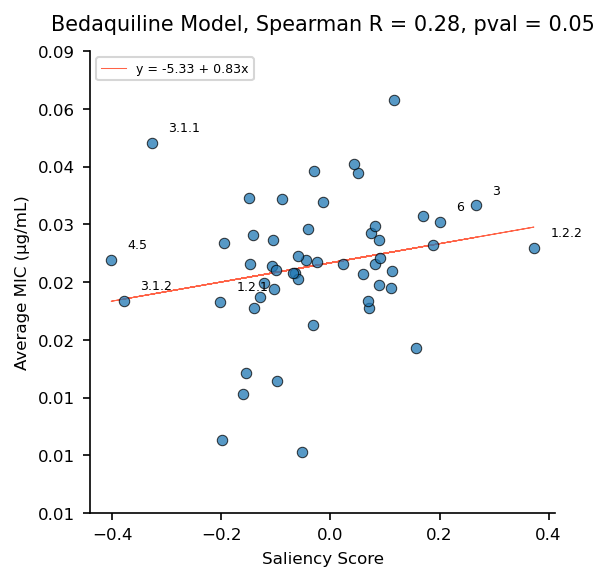

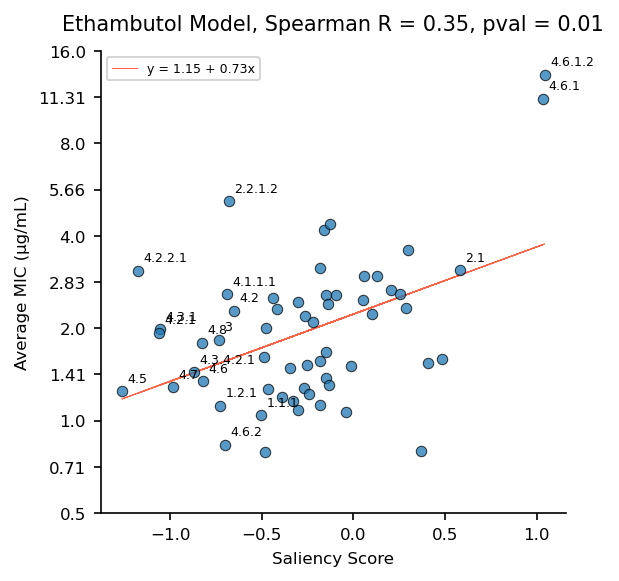

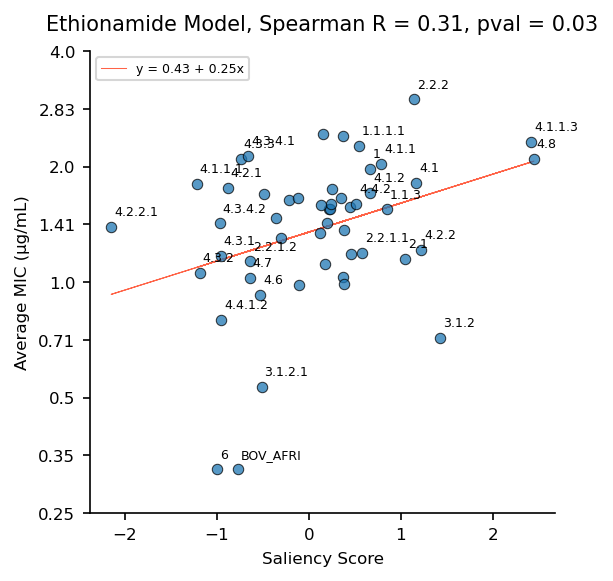

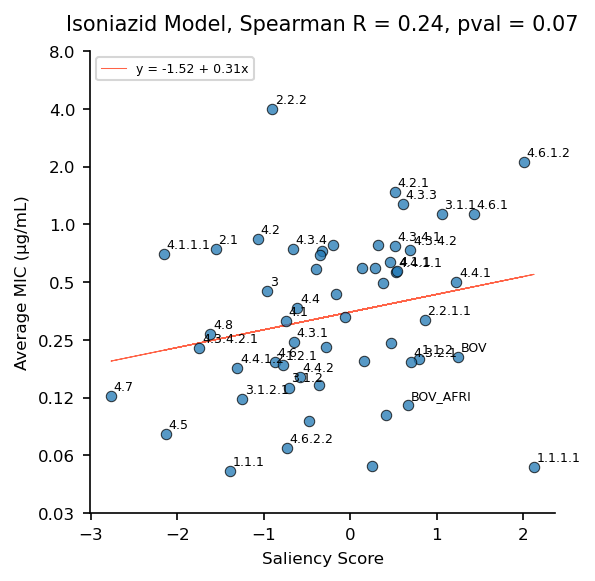

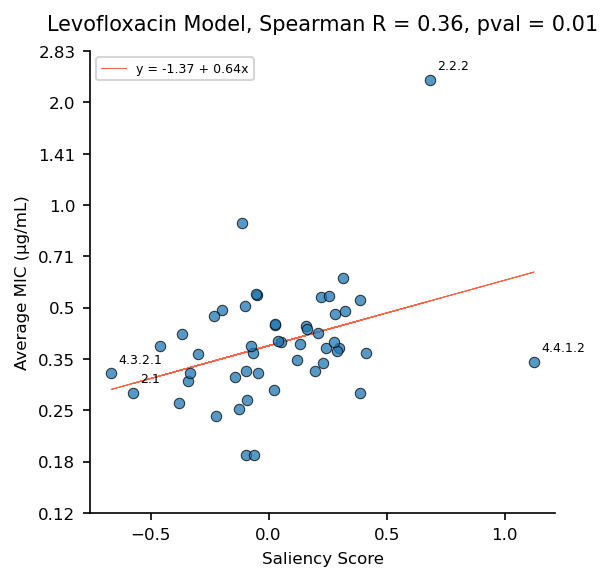

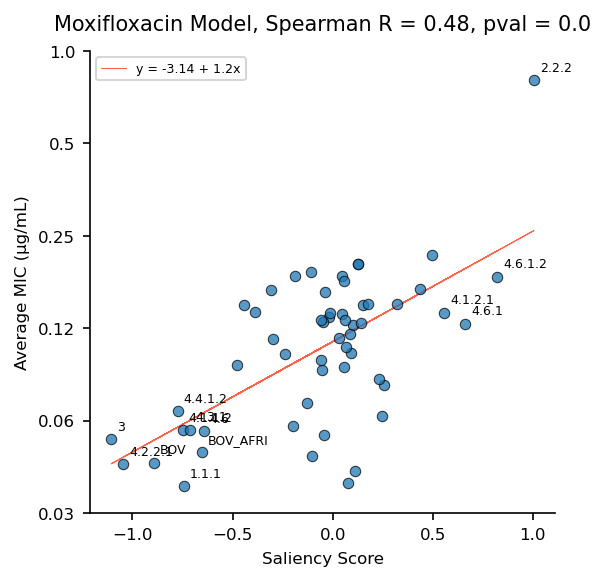

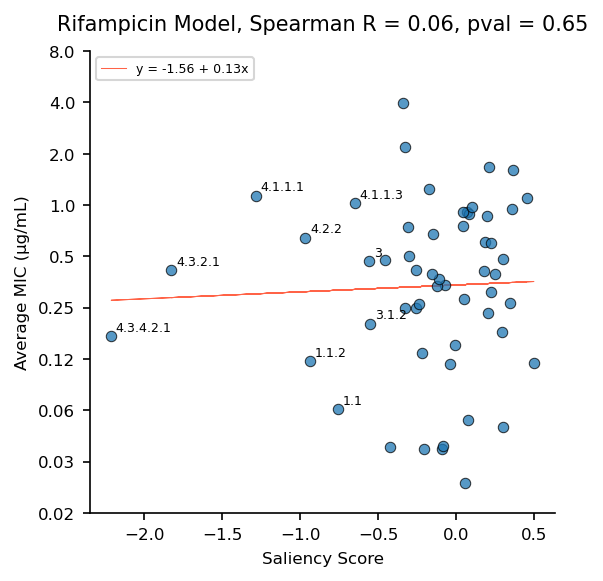

In [13]:
for drug in drugs_lst:    
        
    if drug not in ['PZA']:

        try:
            print(drug)

            if drug == 'BDQ':
                model_path = f"BDQ_augment_lineage_amino_acid"
                annot_thresh = 0.2
            else:
                model_path = f"{drug}_lineage_amino_acid"
                annot_thresh = 0.5

            _ = generate_lineage_saliency_plot(drug,
                                               model_path, 
                                               annot_thresh=annot_thresh,
                                               significance=True,
                                               savefName=f"./results/{abbr_drug_dict[drug]}/lineage_saliency_scatter.svg"
                                             )
            print("\n")
        except:
            print(f"No results files for {drug}\n")

In [ ]:
Moxifloxacin, Bedaquiline, Levofloxacin, Ethionamide, Ethambutol

55/62 lineages have significant saliency scores
55 lineages have at least 2 isolates
In silico CNN prediction for H37Rv: 0.058


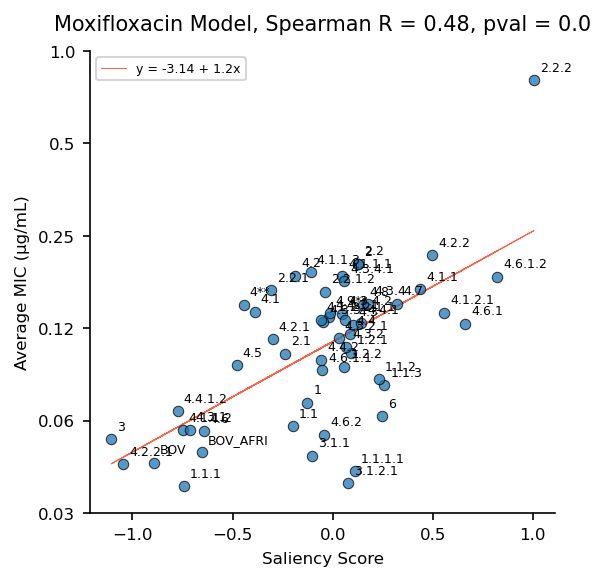

In [24]:
drug = 'MXF'

# model_path = f"{drug}_augment_lineage_amino_acid"
model_path = f"{drug}_lineage_amino_acid"

df_lineages = generate_lineage_saliency_plot(drug,
                                               model_path, 
                                               annot_thresh=0,
                                               significance=True,
                                               # savefName=f"./results/{abbr_drug_dict[drug]}/lineage_saliency_scatter.svg"
                                             )

In [26]:
df_lineages.query("lineage.str.startswith('3')")

,position,Max,Min,lineage,Mean_log2_MIC,log2_MIC,MIC,Num_Isolates,MIC_pval,Max_pval,Min_pval,Bonferroni_MIC_pval,plot_score
16,1084911,-0.000000,-0.102375,3.1.1,-2.834656,-4.382084,0.047958,31.0,2.245737e-06,NaN,0.0,1.302528e-04,-0.102375
18,1237818,0.077953,0.000000,3.1.2.1,-2.834656,-4.679389,0.039027,31.0,4.247079e-08,0.0,NaN,2.463306e-06,0.077953
36,3273107,-0.000000,-1.106462,3,-2.834656,-4.198529,0.054465,491.0,7.264913e-59,NaN,0.0,4.213650e-57,-1.106462


In [25]:
df_lineages.sort_values('plot_score', ascending=False)

,position,Max,Min,lineage,Mean_log2_MIC,log2_MIC,MIC,Num_Isolates,MIC_pval,Max_pval,Min_pval,Bonferroni_MIC_pval,plot_score
2,346693,1.005367,0.000000,2.2.2,-2.834656,-0.313074,0.804925,311.0,2.809590e-79,0.0,NaN,1.629562e-77,1.005367
22,1501468,0.821159,0.000000,4.6.1.2,-2.834656,-2.444484,0.183712,2.0,3.817224e-01,0.0,NaN,2.213990e+01,0.821159
50,4260268,0.662659,0.000000,4.6.1,-2.834656,-2.949326,0.129469,4.0,4.311727e-01,0.0,NaN,2.500802e+01,0.662659
1,107794,0.557778,0.000000,4.1.2.1,-2.834656,-2.829400,0.140691,578.0,6.969319e-03,0.0,NaN,4.042205e-01,0.557778
20,1487796,0.495734,0.000000,4.2.2,-2.834656,-2.210825,0.216011,117.0,2.616037e-04,0.0,NaN,1.517301e-02,0.495734
6,514245,0.438573,0.000000,4.1.1,-2.834656,-2.577321,0.167552,354.0,1.523396e-04,0.0,NaN,8.835694e-03,0.438573
49,4249732,0.322319,0.000000,4.7,-2.834656,-2.736248,0.150075,48.0,1.188828e-01,0.0,NaN,6.895204e+00,0.322319
21,1491275,0.257781,0.000000,1.1.3,-2.834656,-3.616944,0.081506,23.0,5.236339e-02,0.0,NaN,3.037077e+00,0.257781
25,1816587,0.245271,0.000000,6,-2.834656,-3.954167,0.064517,2.0,1.795800e-01,0.0,NaN,1.041564e+01,0.245271
31,2622402,0.229053,0.000000,1.1.2,-2.834656,-3.551538,0.085287,101.0,8.177375e-05,0.0,NaN,4.742877e-03,0.229053


In [ ]:
drug = 'PZA'

model_path = f"{drug}_lineage_amino_acid"

df_lineage_saliency = generate_lineage_saliency_plot(drug,
                                   model_path, 
                                   annot_thresh=0.5,
                                   significance=True,
                                   savefName=f"./results/{abbr_drug_dict[drug]}/lineage_saliency_scatter.svg"
                                 )

In [ ]:
# for PZA, 1.2.2 and 4.3.2.1 had predictions > 100 (actually > 500)
df_lineage_saliency.query("Lineage in ['1', '1.2', '1.2.2']")

In [ ]:
df_lineage_saliency.query("Lineage in ['4**', '4.3', '4.3.2', '4.3.2.1']")